In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_dataset_new.csv")

In [3]:
X = df.drop(columns=["status_encoded"])
y = df["status_encoded"]

In [4]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [6]:

X_resampled.shape

(178216, 26)

In [7]:

y_resampled.shape

(178216,)

In [8]:
y_resampled.value_counts()

,count
status_encoded,
3,44554
0,44554
1,44554
2,44554


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

In [10]:
pca = PCA(n_components=12)  # keep 95% of variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [11]:
# After running SMOTE and PCA above:

# Convert PCA output back to DataFrame
X_train_pca_df = pd.DataFrame(
    X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]
)

# Concatenate with resampled target
train_final_df = pd.concat([X_train_pca_df, y_train.reset_index(drop=True)], axis=1)

# Now train_final_df contains PCA features + target
print(train_final_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -3.022270  3.629724 -1.297372  1.095404 -0.174266 -1.918358 -0.401848   
1  2.530220  1.462328  1.866744  0.375309 -0.285500 -0.867883 -0.379886   
2  0.460680 -0.381789 -0.784586  0.002632  0.078460  0.274160  0.261282   
3  0.021430 -0.864303 -1.003394  0.546308 -0.739690 -1.240079  0.148883   
4  0.845872 -0.224802 -1.607624  0.753813 -0.347962 -1.420530  0.303256   

        PC8       PC9      PC10      PC11      PC12  status_encoded  
0 -1.160297 -0.981036  0.471549 -2.321193  2.465057               2  
1 -0.114878 -0.103360  0.415390  0.054306  0.000182               1  
2  0.339068 -0.256436 -0.591261  0.459979 -0.324460               3  
3  0.008817 -0.176013 -0.269834  0.328624 -0.982434               3  
4  0.062276 -1.458466 -1.021525 -0.414006 -0.098766               3  


In [12]:

train_final_df.to_csv('Final training dataset (PCA 12) (With Upsampling Before Spliting).csv', index=False)

In [13]:
# Convert PCA-transformed test set back to DataFrame
X_test_pca_df = pd.DataFrame(
    X_test_pca, columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])]
)

# Concatenate with the original test target
test_final_df = pd.concat([X_test_pca_df, y_test.reset_index(drop=True)], axis=1)


# Now train_final_df contains PCA features + target
print(test_final_df.head())


        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.162546 -0.425712 -0.940444 -3.839686  5.156210 -1.681811  0.957436   
1 -0.657053 -0.853910 -0.330765 -0.465030 -0.186693  0.235144 -0.051947   
2  2.734204  1.406427  1.191952  1.016942 -0.343294 -1.309768 -0.368462   
3  0.330370 -0.353376 -0.905470 -0.028541  0.043575 -0.315454  0.252447   
4  1.938515  1.021080  0.214485  0.399815  0.099321 -0.129079 -0.193584   

        PC8       PC9      PC10      PC11      PC12  status_encoded  
0 -0.715141 -1.653219 -0.942519 -0.832853  0.006276               0  
1  0.266317  0.343847 -0.119807  0.239754  0.510484               2  
2 -0.403827 -0.094555  1.086650  0.111646 -0.446080               1  
3  0.426821 -1.190422 -1.246478 -0.288987  0.535881               3  
4 -0.393636  0.117613  0.610657 -0.097685  0.601343               3  


In [14]:

test_final_df.to_csv("Final Testing Dataset (PCA 12) (With Upsampling Before Spliting).csv", index=False)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [17]:
train_df = pd.read_csv('Final training dataset (PCA 12) (With Upsampling Before Spliting).csv')
test_df = pd.read_csv('Final Testing Dataset (PCA 12) (With Upsampling Before Spliting).csv')


In [18]:
x_train = train_df.drop(columns=["status_encoded"])
y_train = train_df["status_encoded"]


In [19]:
x_test = test_df.drop(columns=["status_encoded"])
y_test = test_df["status_encoded"]

In [20]:

# For SVM
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# For Decision Tree
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [21]:
svm = SVC(probability=True)


Accuracy: 0.9337

              precision    recall  f1-score   support

           0       0.14      0.01      0.01       387
           1       0.11      0.01      0.01       199
           2       0.00      0.00      0.00        27
           3       0.94      1.00      0.97      8911

    accuracy                           0.93      9524
   macro avg       0.30      0.25      0.25      9524
weighted avg       0.88      0.93      0.90      9524



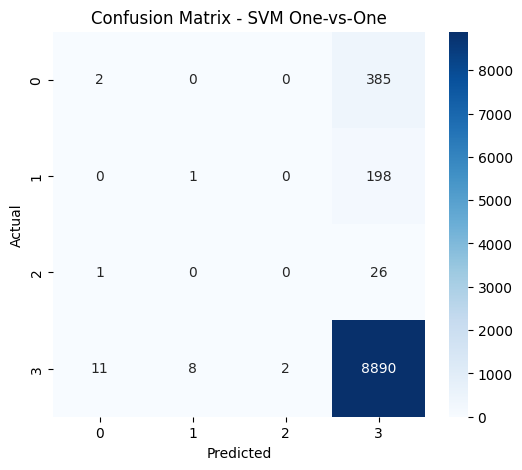

In [27]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Encode target variable
le = LabelEncoder()
df["status_encoded"] = le.fit_transform(df["status_encoded"])

X = df.drop("status_encoded", axis=1)
y = df["status_encoded"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================
# Train Fast Linear SVM
# =======================
svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    dual=False
)

svm.fit(X_train_scaled, y_train)

#Train One-vs-One SVM
# ============================
ovo_svm = OneVsOneClassifier(SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
ovo_svm.fit(X_train_scaled, y_train)

# Predictions
y_pred = ovo_svm.predict(X_test_scaled)

# ============================
# Evaluation Metrics
# ============================
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in le.classes_]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM One-vs-One")
plt.show()


In [32]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =======================
# Load dataset
# =======================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_dataset_new.csv")

# Encode target variable
le = LabelEncoder()
df["status_encoded"] = le.fit_transform(df["status_encoded"])

X = df.drop("status_encoded", axis=1)
y = df["status_encoded"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================
# Train Fast Linear SVM
# =======================
svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    dual=False
)

svm.fit(X_train_scaled, y_train)

# =======================
# Evaluate
# =======================
y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=[str(c) for c in le.classes_]
))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.8966820663586729

Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.02      0.03       387
           1       0.05      0.07      0.06       199
           2       0.07      0.44      0.12        27
           3       0.94      0.95      0.95      8911

    accuracy                           0.90      9524
   macro avg       0.31      0.37      0.29      9524
weighted avg       0.89      0.90      0.89      9524


Confusion Matrix:
 [[   7   13   21  346]
 [   0   14    0  185]
 [   3    0   12   12]
 [  34  234  136 8507]]
